In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [ ]:
np.random.seed(0)

In [ ]:
num_patients = 10000

data = {
    "Patient_ID": np.random.choice(np.arange(10000, 99999), size=10000, replace=False),
    "Age": np.random.randint(20, 81, num_patients),
    "Gender": np.random.choice(["Male", "Female"], num_patients),
    "Blood_Pressure": np.random.randint(80, 181, num_patients),
    "Sugar_Level": np.random.randint(70, 201, num_patients),
    "Cholesterol": np.random.randint(150, 301, num_patients),
    "Heart_Rate": np.random.randint(60, 121, num_patients)
}

data = pd.DataFrame(data)
data

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate
0,76710,70,Female,134,132,237,72
1,83506,43,Male,117,165,170,91
2,53477,26,Female,174,158,278,114
3,87694,35,Male,139,104,275,68
4,62417,33,Female,111,71,286,119
...,...,...,...,...,...,...,...
9995,83651,22,Female,124,111,165,80
9996,20466,39,Female,84,176,202,104
9997,94887,23,Female,134,132,280,106
9998,54260,46,Male,168,128,253,89


In [ ]:
print("Means:\n")
print(data[['Blood_Pressure', 'Sugar_Level', 'Cholesterol', 'Heart_Rate']].mean())

Means:

Blood_Pressure    130.8783
Sugar_Level       135.3843
Cholesterol       224.8462
Heart_Rate         89.7735
dtype: float64


In [ ]:
print("Medians:\n")
print(data[['Blood_Pressure', 'Sugar_Level', 'Cholesterol', 'Heart_Rate']].median())

Medians:

Blood_Pressure    131.0
Sugar_Level       136.0
Cholesterol       225.0
Heart_Rate         89.0
dtype: float64


In [ ]:
print("Modes:\n")
print(data[['Blood_Pressure', 'Sugar_Level', 'Cholesterol', 'Heart_Rate']].mode().iloc[0])

Modes:

Blood_Pressure    106
Sugar_Level       185
Cholesterol       158
Heart_Rate         83
Name: 0, dtype: int64


In [ ]:
  def classify_risk(row):
    risk_score = 0

    if row["Blood_Pressure"] > 140:
        risk_score += 1
    if row["Sugar_Level"] > 160:
        risk_score += 1
    if row["Cholesterol"] > 240:
        risk_score += 1
    if row["Heart_Rate"] > 100:
        risk_score += 1

    if risk_score >= 3:
        return "High"
    elif risk_score == 2:
        return "Medium"
    else:
        return "Low"

In [ ]:
data["Risk_Level"] = data.apply(classify_risk, axis=1)
data

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk_Level
0,76710,70,Female,134,132,237,72,Low
1,83506,43,Male,117,165,170,91,Low
2,53477,26,Female,174,158,278,114,High
3,87694,35,Male,139,104,275,68,Low
4,62417,33,Female,111,71,286,119,Medium
...,...,...,...,...,...,...,...,...
9995,83651,22,Female,124,111,165,80,Low
9996,20466,39,Female,84,176,202,104,Medium
9997,94887,23,Female,134,132,280,106,Medium
9998,54260,46,Male,168,128,253,89,Medium


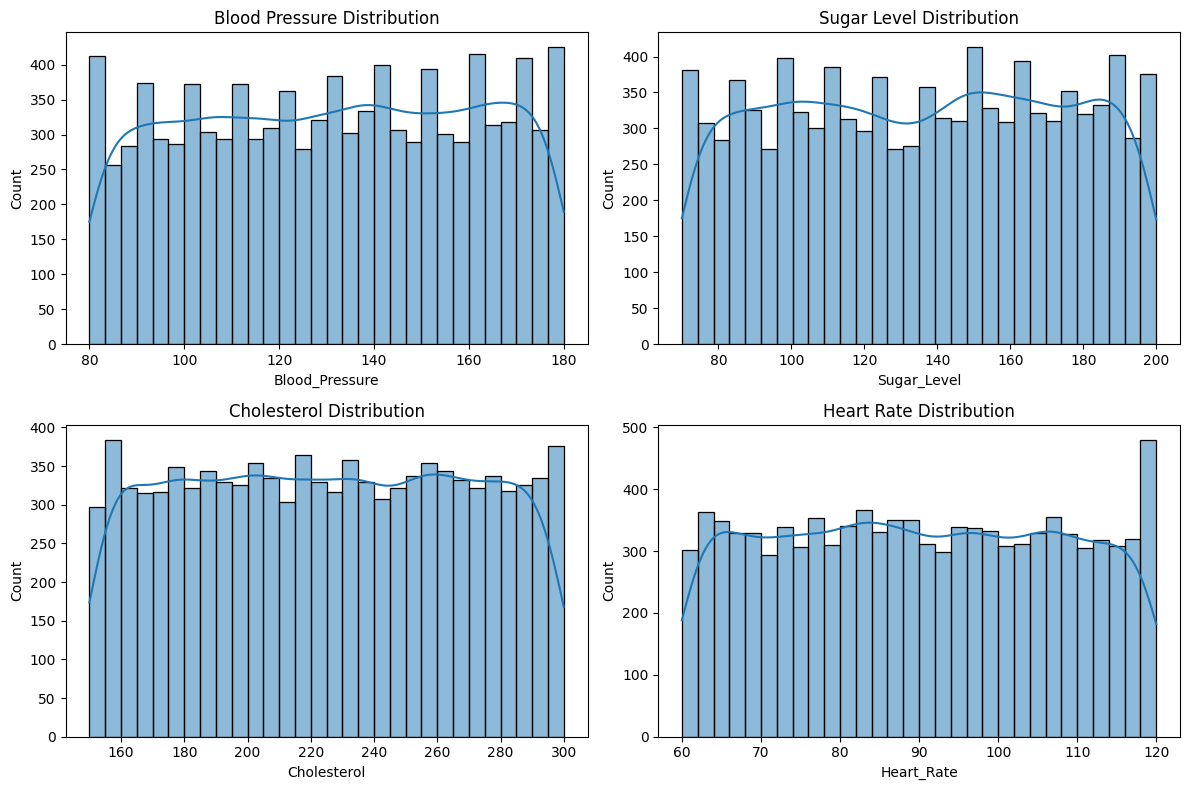

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.histplot(data["Blood_Pressure"], bins=30, kde=True)
plt.title("Blood Pressure Distribution")

plt.subplot(2,2,2)
sns.histplot(data["Sugar_Level"], bins=30, kde=True)
plt.title("Sugar Level Distribution")

plt.subplot(2,2,3)
sns.histplot(data["Cholesterol"], bins=30, kde=True)
plt.title("Cholesterol Distribution")

plt.subplot(2,2,4)
sns.histplot(data["Heart_Rate"], bins=30, kde=True)
plt.title("Heart Rate Distribution")

plt.tight_layout()
plt.show()

In [ ]:
data["Risk_Level"].value_counts()

,count
Risk_Level,
Low,5467
Medium,3197
High,1336


In [ ]:
high_risk_patients = data[data["Risk_Level"] == "High"]

high_risk_patients

,Patient_ID,Age,Gender,Blood_Pressure,Sugar_Level,Cholesterol,Heart_Rate,Risk_Level
2,53477,26,Female,174,158,278,114,High
5,26923,72,Female,144,181,281,102,High
12,60338,26,Female,171,184,296,69,High
22,96538,33,Female,148,166,214,108,High
24,73748,23,Female,160,193,222,105,High
...,...,...,...,...,...,...,...,...
9975,34058,65,Female,143,197,261,93,High
9981,95731,34,Male,92,175,241,107,High
9985,78088,25,Male,149,198,278,62,High
9986,78818,60,Female,95,179,244,115,High


In [ ]:
age_risk_table = data.groupby("Age")["Risk_Level"].value_counts().unstack()

age_risk_table

Risk_Level,High,Low,Medium
Age,,,
20,24,90,47
21,26,105,58
22,19,97,47
23,23,90,40
24,24,98,50
...,...,...,...
76,28,80,67
77,18,101,44
78,16,99,44


<Figure size 640x480 with 0 Axes>

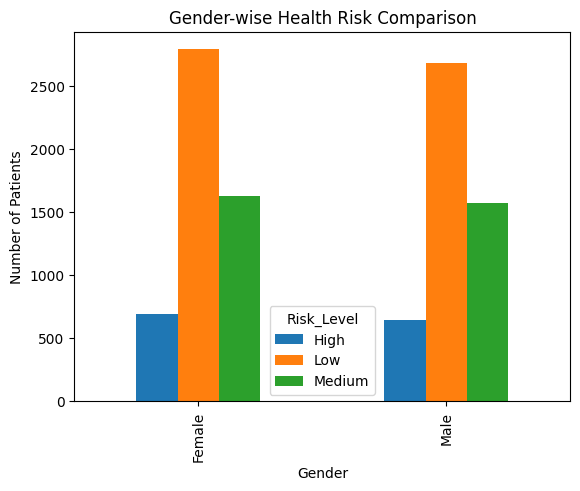

In [ ]:
gender_risk = data.groupby("Gender")["Risk_Level"].value_counts().unstack()
gender_risk

plt.figure()

gender_risk.plot(kind="bar")

plt.title("Gender-wise Health Risk Comparison")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

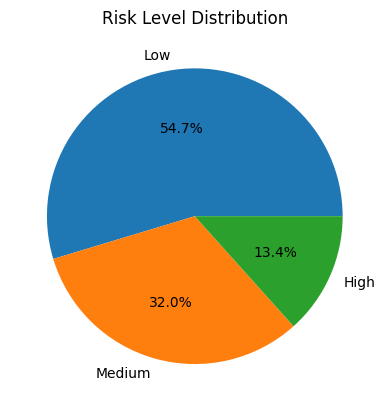

In [ ]:
plt.figure()
data["Risk_Level"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Risk Level Distribution")
plt.ylabel("")
plt.show()

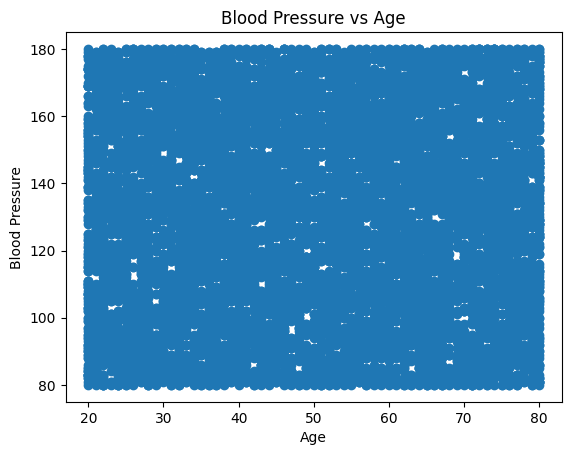

In [ ]:
plt.figure()
plt.scatter(data["Age"], data["Blood_Pressure"])
plt.title("Blood Pressure vs Age")
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.show()

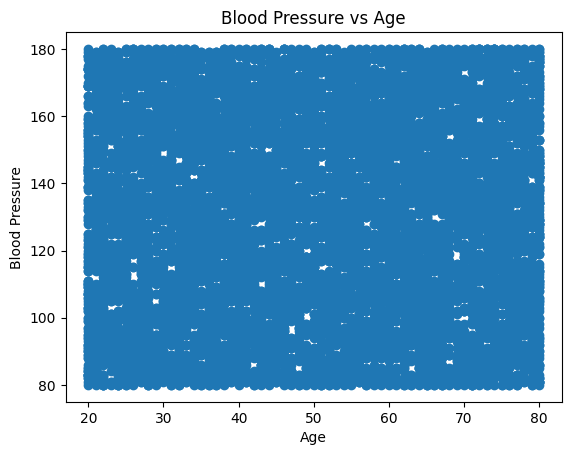

In [ ]:
plt.figure()
plt.scatter(data["Age"], data["Blood_Pressure"])
plt.title("Blood Pressure vs Age")
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.show()

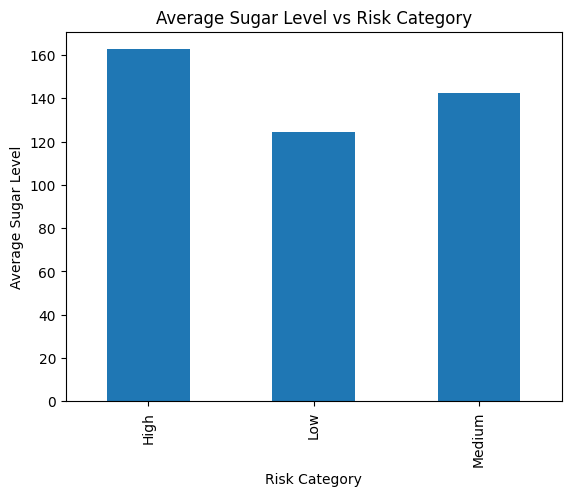

In [ ]:
plt.figure()

sugar_risk.plot(kind="bar")

plt.title("Average Sugar Level vs Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Sugar Level")

plt.show()

In [ ]:
print("Total Patients:", len(data))
print("Medium Risk Patients:", len(data[data["Risk_Level"]=="High"]))
print("Medium Risk Patients:", len(data[data["Risk_Level"]=="Medium"]))
print("Low Risk Patients:", len(data[data["Risk_Level"]=="Low"]))

Total Patients: 10000
Medium Risk Patients: 1336
Medium Risk Patients: 3197
Low Risk Patients: 5467


In [ ]:
data.to_csv("healthcare_patient_data.csv", index=False)
print("Dataset saved successfully")

Dataset saved successfully
